---
numbering:
  title: false
  headings: false
---

(sec:project_tlc_mobile_phase_prediction)=

# Predicting TLC mobile phase composition for organic molecules


## Background

Our aim was to implement a model that predicts Rf values for given mobile phase compositions and thus predicting the optimal composition for the wanted molecule. 
    
The principle of TLC is based on interactions between the stationary phase (in our case silica) and the mobile phase. 
How far the substance is carried depends on different factors, such as the polarity or the ability to form H-bonds of the molecule and the mobile phase and is measured by the Rf value. This is illustrated in the picture below. 

The optimal range for the Rf value is between 0.2 and 0.4.

<img src="/assets/figures/projects/rf_bild.png" width="500" style="display: block; margin: auto;">

## Assets

Download the TLC dataset here: {download}`/assets/data/projects/data3.CSV`.


We used information and data by https://www.sciencedirect.com/science/article/pii/S2451929422004211. The compiled dataset is provided above for download.

## Implementation



In [19]:
from rdkit import Chem
from rdkit.Chem import Crippen, rdMolDescriptors, Descriptors
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor

In [20]:
df = pd.read_csv('../../assets/data/projects/data3.CSV', sep=";")
df.head()

,Unnamed: 0,TLC_ID,COMPOUND_ID,SMILES,H,EA,DCM,MeOH,Rf
0,0,1,1,O=C(C1=CC=CC=C1)CCCl,1.000000,0.000000,0.0,0.0,0.049175
1,1,2,1,O=C(C1=CC=CC=C1)CCCl,0.980392,0.019608,0.0,0.0,0.262708
2,2,3,1,O=C(C1=CC=CC=C1)CCCl,0.952381,0.047619,0.0,0.0,0.410200
3,3,4,1,O=C(C1=CC=CC=C1)CCCl,0.833333,0.166667,0.0,0.0,0.719773
4,4,5,1,O=C(C1=CC=CC=C1)CCCl,0.750000,0.250000,0.0,0.0,0.794856


For molecular representation we used SMILES.
We defined the function get_molecule_descriptors to characterize our molecules with the following descriptors: 
1. LogP: partition coefficient to determine the lipophilia of a molecule
2. TPSA: topological polar surface area
3. NumHDonors: Number of H-Donors
4. NumHAcceptors: Number of H-Acceptors
5. MolWt: Molecular weight

In [21]:
def get_molecule_descriptors(smiles):
    mol = Chem.MolFromSmiles(smiles)

    if mol is None:
        raise ValueError(f"Ungültiger SMILES: {smiles}")

    return {
        "MolLogP": Crippen.MolLogP(mol),
        "TPSA": rdMolDescriptors.CalcTPSA(mol),
        "NumHDonors": rdMolDescriptors.CalcNumHBD(mol),
        "NumHAcceptors": rdMolDescriptors.CalcNumHBA(mol),
        "MolWt": Descriptors.MolWt(mol),
    }

In order to get our X-data, we created a data frame containing our molecules and their descriptors as well as the corresponding mobile phase components, that we extracted from our dataset.

In [22]:
descriptors_data = []

for smiles in df['SMILES']:
    descriptors = get_molecule_descriptors(smiles)
    descriptors_data.append(descriptors)

descriptors_df = pd.DataFrame(descriptors_data)

X_final = pd.concat([df[['H', 'EA', 'DCM', 'MeOH']], descriptors_df], axis=1)
X_final.head()

,H,EA,DCM,MeOH,MolLogP,TPSA,NumHDonors,NumHAcceptors,MolWt
0,1.000000,0.000000,0.0,0.0,2.4982,17.07,0,1,168.623
1,0.980392,0.019608,0.0,0.0,2.4982,17.07,0,1,168.623
2,0.952381,0.047619,0.0,0.0,2.4982,17.07,0,1,168.623
3,0.833333,0.166667,0.0,0.0,2.4982,17.07,0,1,168.623
4,0.750000,0.250000,0.0,0.0,2.4982,17.07,0,1,168.623


Our target y is the corresponding Rf-value:

In [23]:
y_final = df['Rf']
pd.DataFrame(y_final.head())

,Rf
0,0.049175
1,0.262708
2,0.410200
3,0.719773
4,0.794856


The next step is splitting into training and test data.

In [24]:
X_train, X_test, y_train, y_test = train_test_split(X_final, y_final, test_size=0.2, random_state=None)

Our model of choice was RandomForestRegressor. 

In [25]:
model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In order to illustrate the accuracy of our model we plotted the predicted Rf values against the actual Rf values from the test-dataset. 

MAE: 0.08788550243948906
MSE: 0.01676445502245679
R2: 0.851249076429125


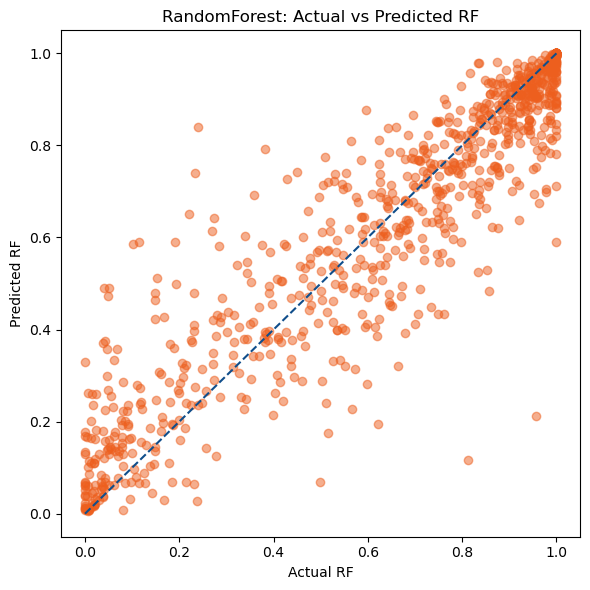

In [26]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

y_pred = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.5, color='#ED5F1E')
plt.plot([0, 1], [0, 1], "--", color='#104E8B')
plt.xlabel("Actual RF")
plt.ylabel("Predicted RF")
plt.title("RandomForest: Actual vs Predicted RF")
plt.tight_layout()
plt.show()

The small MAE and MSE values and the R2 value close to 1 underline the acceptable accuracy of our model. 

## Application
Our model is now fully trained and ready to be used.
You just have to insert the SMILES of your wanted molecule and let the model predict the optimal composition of a mobile phase system of hexane and ethylacetat or dichloromethan and methanol. 

In [27]:
#melatonin: CC(=O)NCCC1=CNC2=C1C=C(C=C2)OC
#anilin: Nc1ccccc1

#OP1 examples:
#cis-1,2-cyclohexandiol:  C1CC[C@@H]([C@@H](C1)O)O
#isobutenylbenzene: CC(C)=CC1=CC=CC=C1

smiles_new = 'CC(C)=CC1=CC=CC=C1'
desc_new = get_molecule_descriptors(smiles_new)
desc_new_df = pd.DataFrame([desc_new])

In [28]:
results_h_ea = []

for hexan in np.arange(0.0, 1.1, 0.1):
    ethylacetat = 1 - hexan

    laufmittel_df = pd.DataFrame([{
        'H': hexan,
        'EA': ethylacetat,
        'DCM': 0,
        'MeOH': 0
            
    }])

    X_neu = pd.concat([laufmittel_df, desc_new_df], axis=1)
    X_neu = X_neu[X_final.columns]

   
    rf_pred = model.predict(X_neu)[0]

    results_h_ea.append({
        'SMILES': smiles_new,
        'H': hexan,
        'EA': ethylacetat,
        'RF_pred': rf_pred
    })

results_h_ea_df = pd.DataFrame(results_h_ea)

In [29]:
target = 0.30

closest_idx = (results_h_ea_df["RF_pred"] - target).abs().idxmin()
def highlight_closest(row):
    if row.name == closest_idx:
        return ["background-color: yellow"] * len(row)
    else:
        return [""] * len(row)
display(results_h_ea_df.style.apply(highlight_closest, axis=1))

,SMILES,H,EA,RF_pred
0,CC(C)=CC1=CC=CC=C1,0.000000,1.000000,0.995048
1,CC(C)=CC1=CC=CC=C1,0.100000,0.900000,0.995048
2,CC(C)=CC1=CC=CC=C1,0.200000,0.800000,0.995958
3,CC(C)=CC1=CC=CC=C1,0.300000,0.700000,0.996064
4,CC(C)=CC1=CC=CC=C1,0.400000,0.600000,0.996064
5,CC(C)=CC1=CC=CC=C1,0.500000,0.500000,0.995041
6,CC(C)=CC1=CC=CC=C1,0.600000,0.400000,0.995041
7,CC(C)=CC1=CC=CC=C1,0.700000,0.300000,0.941359
8,CC(C)=CC1=CC=CC=C1,0.800000,0.200000,0.900900
9,CC(C)=CC1=CC=CC=C1,0.900000,0.100000,0.759840


## Experimental Data
<img src="/assets/figures/projects/dc_bild.jpeg" width="700" style="display: block; margin: auto;">
left: isobutenylbenzene; right: cis-1,2-cyclohexanediol

In [30]:
results_dcm_meoh = []

for dichlormethan in np.arange(0.0, 1.1, 0.1):
    methanol = 1 - dichlormethan

    laufmittel_df = pd.DataFrame([{
        'H': 0,
        'EA': 0,
        'DCM': dichlormethan,
        'MeOH': methanol
    }])

    X_neu = pd.concat([laufmittel_df, desc_new_df], axis=1)
    X_neu = X_neu[X_final.columns]

   
    rf_pred = model.predict(X_neu)[0]

    results_dcm_meoh.append({
        'SMILES': smiles_new,
        'DCM': dichlormethan,
        'MeOH': methanol,
        'RF_pred': rf_pred
    })

results_dcm_meoh_df = pd.DataFrame(results_dcm_meoh)

In [31]:
target = 0.30

closest_idx = (results_dcm_meoh_df["RF_pred"] - target).abs().idxmin()
def highlight_closest(row):
    if row.name == closest_idx:
        return ["background-color: yellow"] * len(row)
    else:
        return [""] * len(row)
display(results_dcm_meoh_df.style.apply(highlight_closest, axis=1))

,SMILES,DCM,MeOH,RF_pred
0,CC(C)=CC1=CC=CC=C1,0.000000,1.000000,0.998409
1,CC(C)=CC1=CC=CC=C1,0.100000,0.900000,0.998409
2,CC(C)=CC1=CC=CC=C1,0.200000,0.800000,0.998409
3,CC(C)=CC1=CC=CC=C1,0.300000,0.700000,0.998409
4,CC(C)=CC1=CC=CC=C1,0.400000,0.600000,0.998409
5,CC(C)=CC1=CC=CC=C1,0.500000,0.500000,0.999859
6,CC(C)=CC1=CC=CC=C1,0.600000,0.400000,0.999859
7,CC(C)=CC1=CC=CC=C1,0.700000,0.300000,0.999859
8,CC(C)=CC1=CC=CC=C1,0.800000,0.200000,0.999859
9,CC(C)=CC1=CC=CC=C1,0.900000,0.100000,0.999859


## Results

In general, the quality of prediction could be improved, but in general, the model delivers satisfying predictions. 
It is still not perfect, so we recommend staying critical and testing your mobile phase experimentally. It is better. 

## Further Questions

Constraints/ Limits:

- For some molecules the best value is still far away from 0.3 (e.g. 0.7)
- Only valid for those specific trained mobile phase systems

Extensions:
- Possible multiple layer neural network (for bigger data set)
- Variation of stationary phases
- More molecular descriptors